# NUMPY IRIS

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import sys

## Загрузка датасета Ирис

In [2]:
iris = load_iris()
X = iris.data  # Матрица признаков (150, 4)
y = iris.target  # Вектор меток (150,)
target_names = iris.target_names

print("Размер матрицы признаков:", X.shape)
print("Размер вектора меток:", y.shape)
print(f"Занимаемое место: {X.nbytes + y.nbytes} байт")

Размер матрицы признаков: (150, 4)
Размер вектора меток: (150,)
Занимаемое место: 5400 байт


## Нормализация данных от 0 до 1

In [3]:
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
print("\nНормализованные данные (первые 5 строк):")
print(X_normalized[:5])


Нормализованные данные (первые 5 строк):
[[0.22222222 0.625      0.06779661 0.04166667]
 [0.16666667 0.41666667 0.06779661 0.04166667]
 [0.11111111 0.5        0.05084746 0.04166667]
 [0.08333333 0.45833333 0.08474576 0.04166667]
 [0.19444444 0.66666667 0.06779661 0.04166667]]


## Представление одного признака в виде категориальной переменной

In [4]:
sepal_length = X_normalized[:, 0]  # Первый признак (длина чашелистика)
categories = np.zeros_like(sepal_length, dtype=object)
categories[sepal_length < 0.25] = 'small'
categories[(sepal_length >= 0.25) & (sepal_length <= 0.75)] = 'medium'
categories[sepal_length > 0.75] = 'big'

print("\nКатегоризация признака 'sepal length':")
print(f"Small: {np.sum(categories == 'small')}")
print(f"Medium: {np.sum(categories == 'medium')}")
print(f"Big: {np.sum(categories == 'big')}")


Категоризация признака 'sepal length':
Small: 41
Medium: 97
Big: 12


## Разделение на тренировочную и тестовую выборки

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nРазмер тренировочной выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Размер тренировочной выборки: (120, 4)
Размер тестовой выборки: (30, 4)


## Классификация с помощью SVC

In [15]:
svc = SVC(random_state=42)
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность: {accuracy:.4f}")
print("\nОтчет классификации:")
print(classification_report(y_test, y_pred, target_names=target_names))

Точность: 0.9667

Отчет классификации:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



Вывод: Стандартная SVC справляется довольно хорошо. Задача практически решена.

## Эксперименты: Разные гиперпараметры (ядра)

In [7]:
kernels = ['linear', 'rbf', 'poly']
for kernel in kernels:
    svc_exp = SVC(kernel=kernel, random_state=42)
    svc_exp.fit(X_train, y_train)
    y_pred_exp = svc_exp.predict(X_test)
    accuracy_exp = accuracy_score(y_test, y_pred_exp)
    print(f"Ядро {kernel}: Точность = {accuracy_exp:.4f}") 

Ядро linear: Точность = 0.9333
Ядро rbf: Точность = 0.9667
Ядро poly: Точность = 1.0000


Вывод: poly показало идеальный результат

### Уменьшение размерности и обучение SVC

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normalized)


best_svc = SVC(kernel='poly', random_state=42)
best_svc.fit(X_train, y_train)
y_pred_full = best_svc.predict(X_normalized)

### Вывод графиков

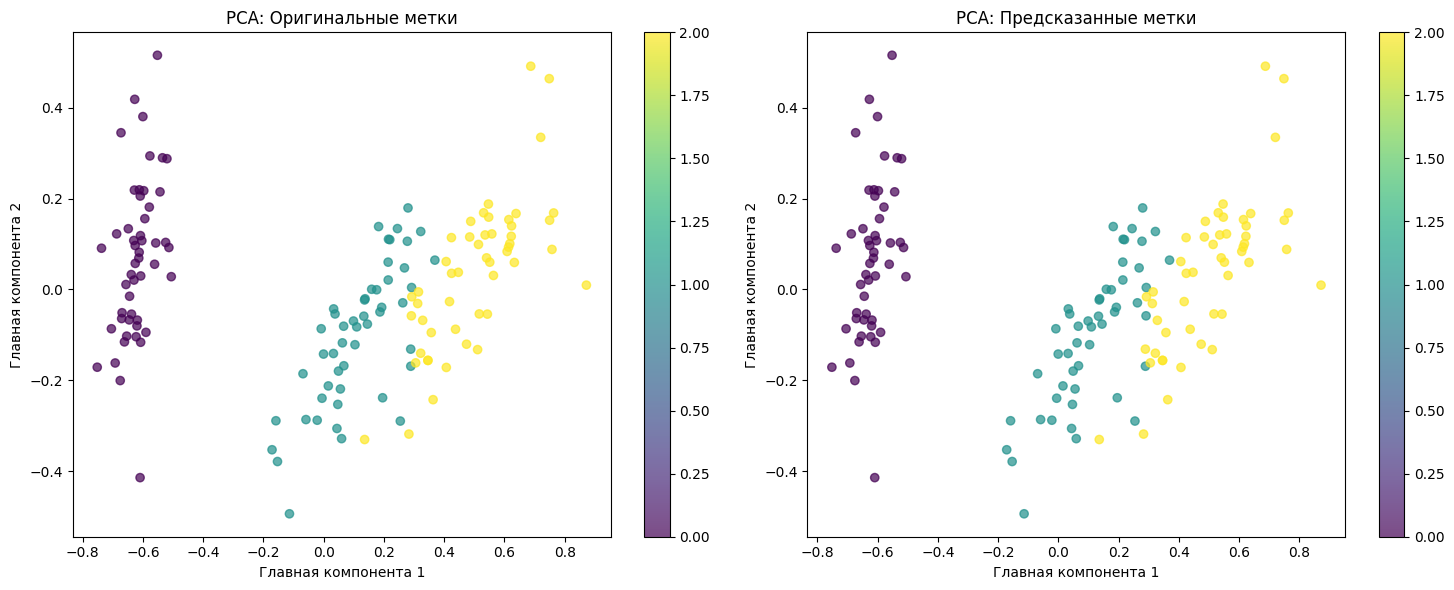

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: PCA с предсказанными метками
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
axes[0].set_title('PCA: Оригинальные метки')
axes[0].set_xlabel('Главная компонента 1')
axes[0].set_ylabel('Главная компонента 2')
plt.colorbar(scatter1, ax=axes[0])

# График 2: PCA с предсказанными метками
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_full, cmap='viridis', alpha=0.7)
axes[1].set_title('PCA: Предсказанные метки')
axes[1].set_xlabel('Главная компонента 1')
axes[1].set_ylabel('Главная компонента 2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()